<a href="https://colab.research.google.com/github/PradeepTiwari12/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Cell 1: Install & Import Libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 11

print('Setup complete. Libraries loaded successfully.')

Setup complete. Libraries loaded successfully.


In [4]:
# Cell 2: Load and inspect dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset (3).csv')

print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
print('\nData Types:')
print(df.dtypes)
print('\nMissing Value Summary:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: 4000 rows, 28 columns

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue

In [5]:
# Cell 3: Preprocessing & Imputation
# Impute missing values using group-level medians
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df.groupby('Season')['Rainfall_mm'].transform('median')
)
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df.groupby('Season')['Soil_Moisture_pct'].transform('median')
)
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform('median')
)

# Feature engineering
df['Profit_Margin_pct'] = np.where(
    df['Revenue_INR'] > 0, (df['Profit_INR'] / df['Revenue_INR']) * 100, 0
)
df['Cost_Per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']

print('Missing values after imputation:', df.isnull().sum().sum())
df[['Farm_ID', 'Season', 'Crop', 'Yield_Tonnes_Ha', 'Profit_INR']].head()

Missing values after imputation: 0


,Farm_ID,Season,Crop,Yield_Tonnes_Ha,Profit_INR
0,SF10001,Kharif,Wheat,2.46,-11852
1,SF10002,Kharif,Maize,0.30,-451950
2,SF10003,Rabi,Pulses,0.52,-124744
3,SF10004,Kharif,Rice,1.84,-95704
4,SF10005,Zaid,Maize,2.21,-144352


In [6]:
# Cell 4: Seasonal summary statistics
seasonal_metrics = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Water_Used_m3': 'mean',
    'Profit_INR': 'mean',
    'Disease_Pest_Risk_pct': 'mean',
}).round(2)

print('Seasonal Summary Statistics:')
seasonal_metrics

Seasonal Summary Statistics:


,Yield_Tonnes_Ha,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Water_Used_m3,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,852.11,28.45,71.81,6102.20,178914.65,54.47
Rabi,5.09,435.94,23.49,57.89,5846.99,87689.47,40.48
Zaid,4.64,299.12,31.04,52.01,6419.89,-24804.82,38.22


/tmp/ipykernel_2156/560065321.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2156/560065321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2156/560065321.py:32: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2156/560065321.py:33: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('plot1_seasonal_profit.png')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


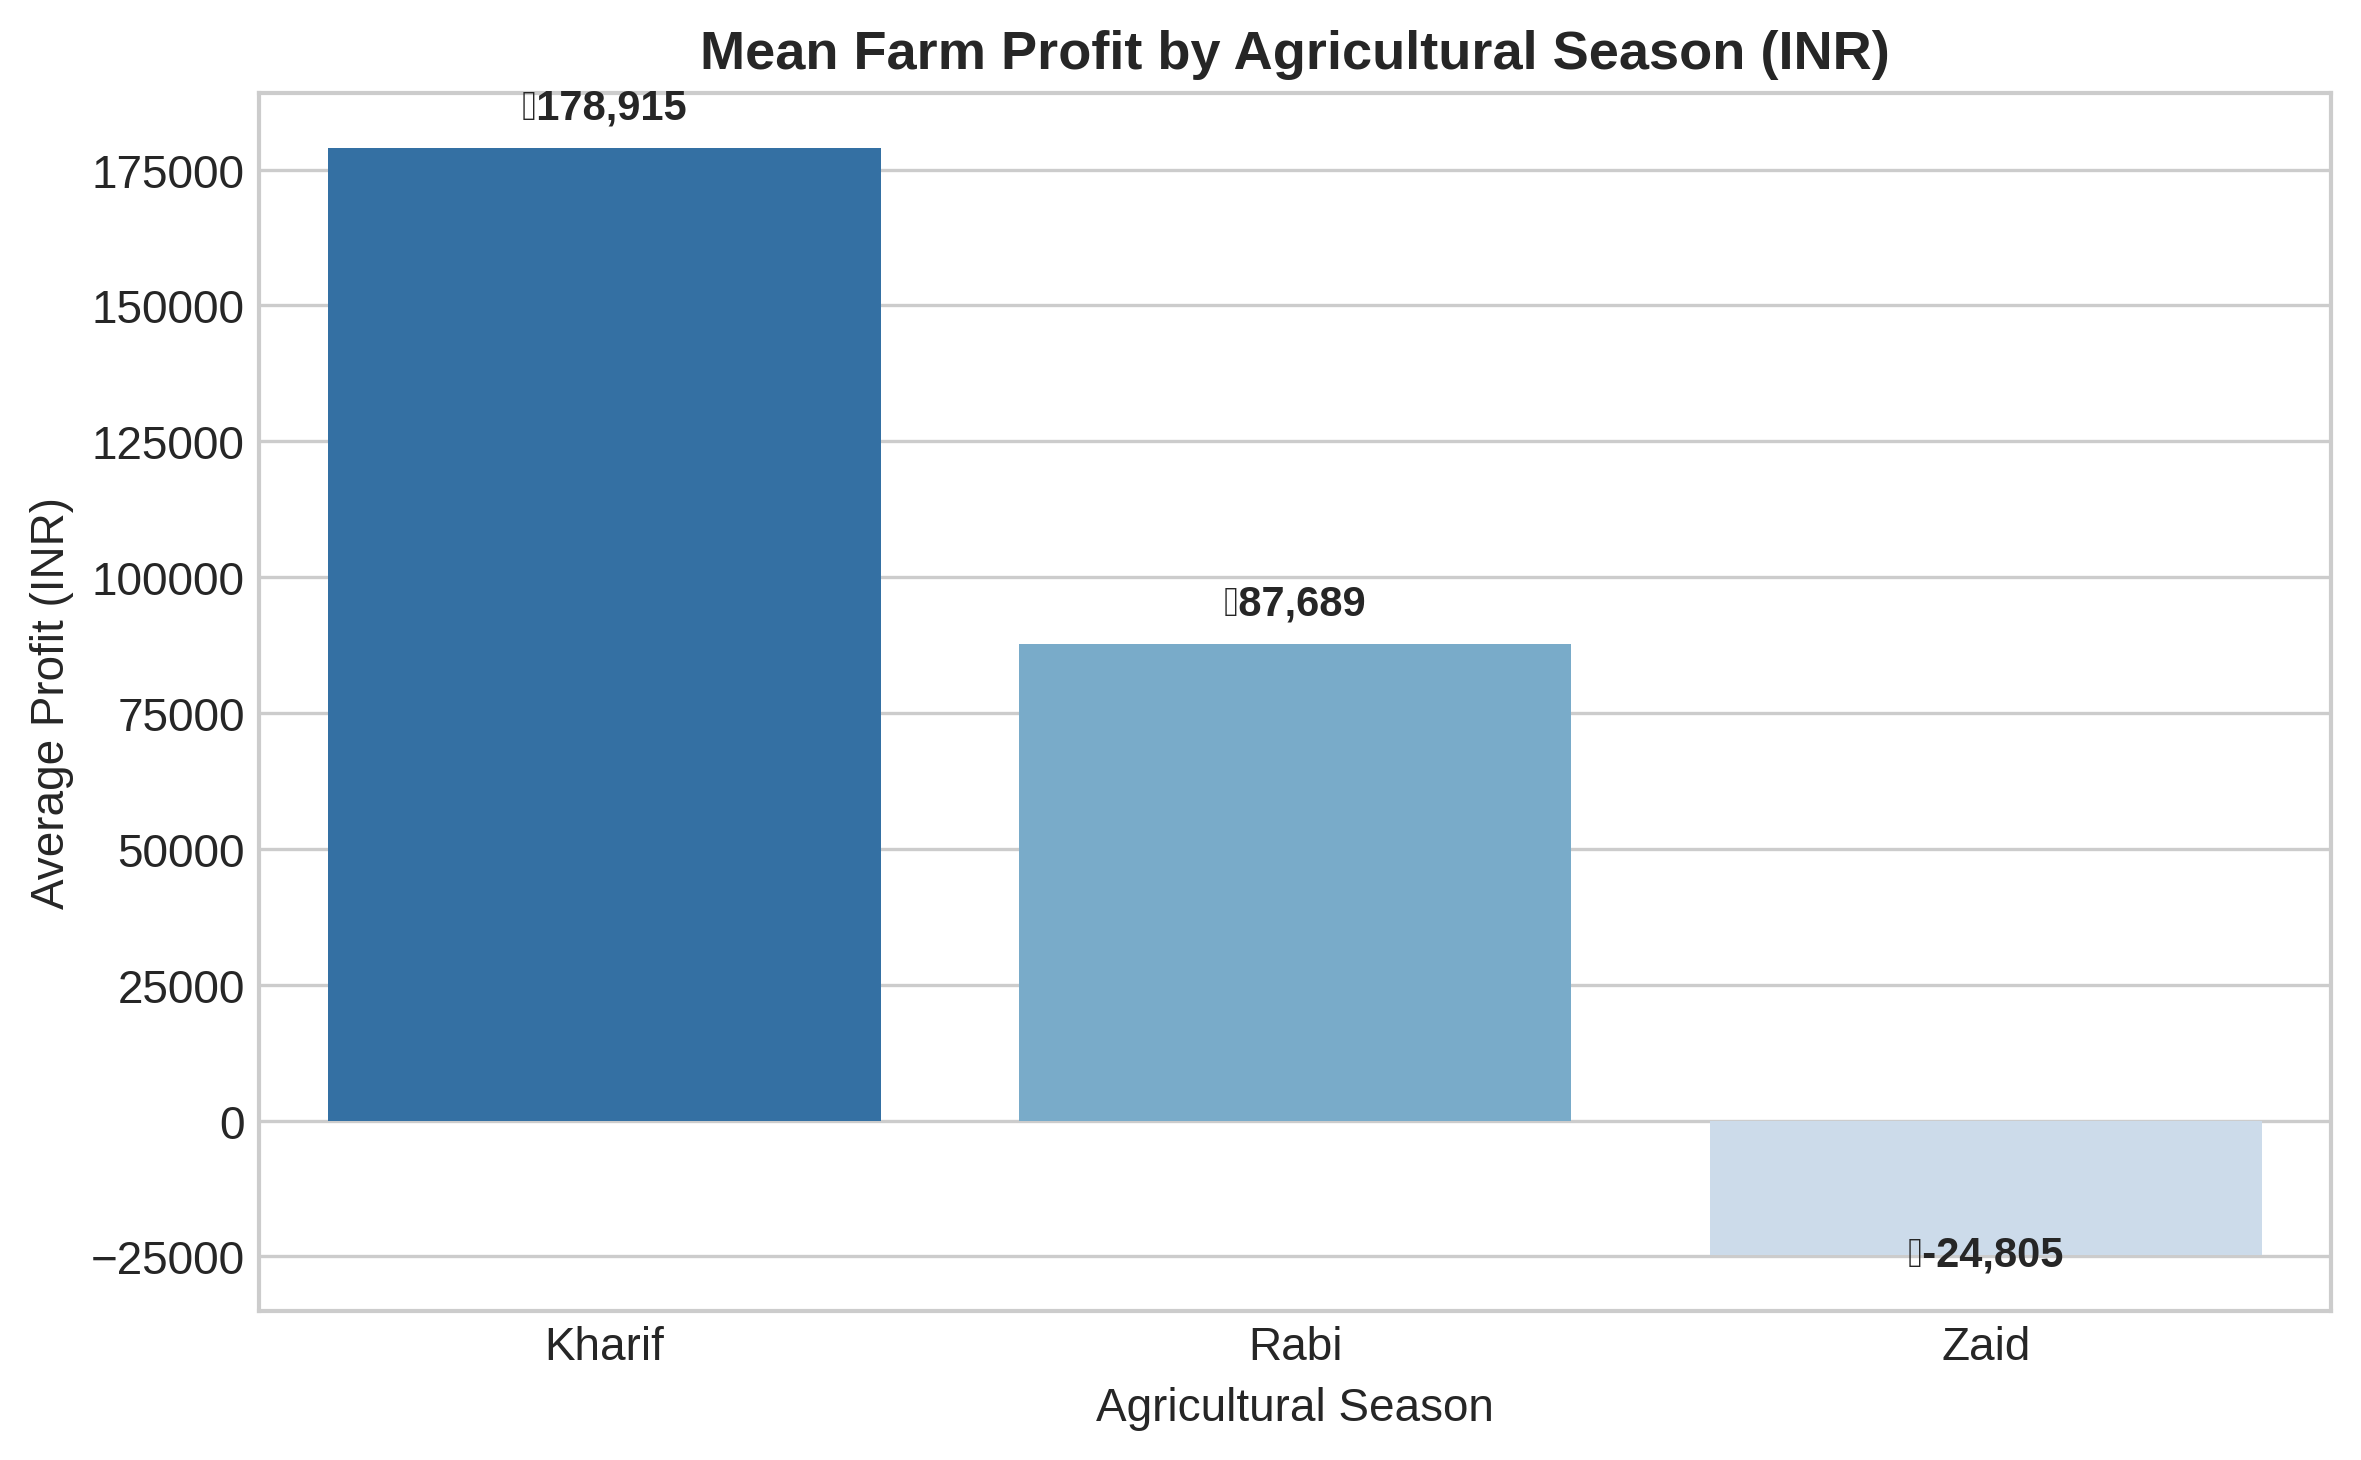

In [7]:
# Cell 5: Seasonal Profit Distribution
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    palette='Blues_r',
    estimator=np.mean,
    ci=None,
)
plt.title(
    'Mean Farm Profit by Agricultural Season (INR)',
    fontsize=13,
    fontweight='bold',
)
plt.ylabel('Average Profit (INR)')
plt.xlabel('Agricultural Season')

for p in ax.patches:
  val = p.get_height()
  ax.annotate(
      f'₹{val:,.0f}',
      (p.get_x() + p.get_width() / 2.0, val),
      ha='center',
      va='bottom' if val >= 0 else 'top',
      fontsize=10,
      fontweight='bold',
      xytext=(0, 5),
      textcoords='offset points',
  )

plt.tight_layout()
plt.savefig('plot1_seasonal_profit.png')
plt.show()

/tmp/ipykernel_2156/3997566830.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2156/3997566830.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


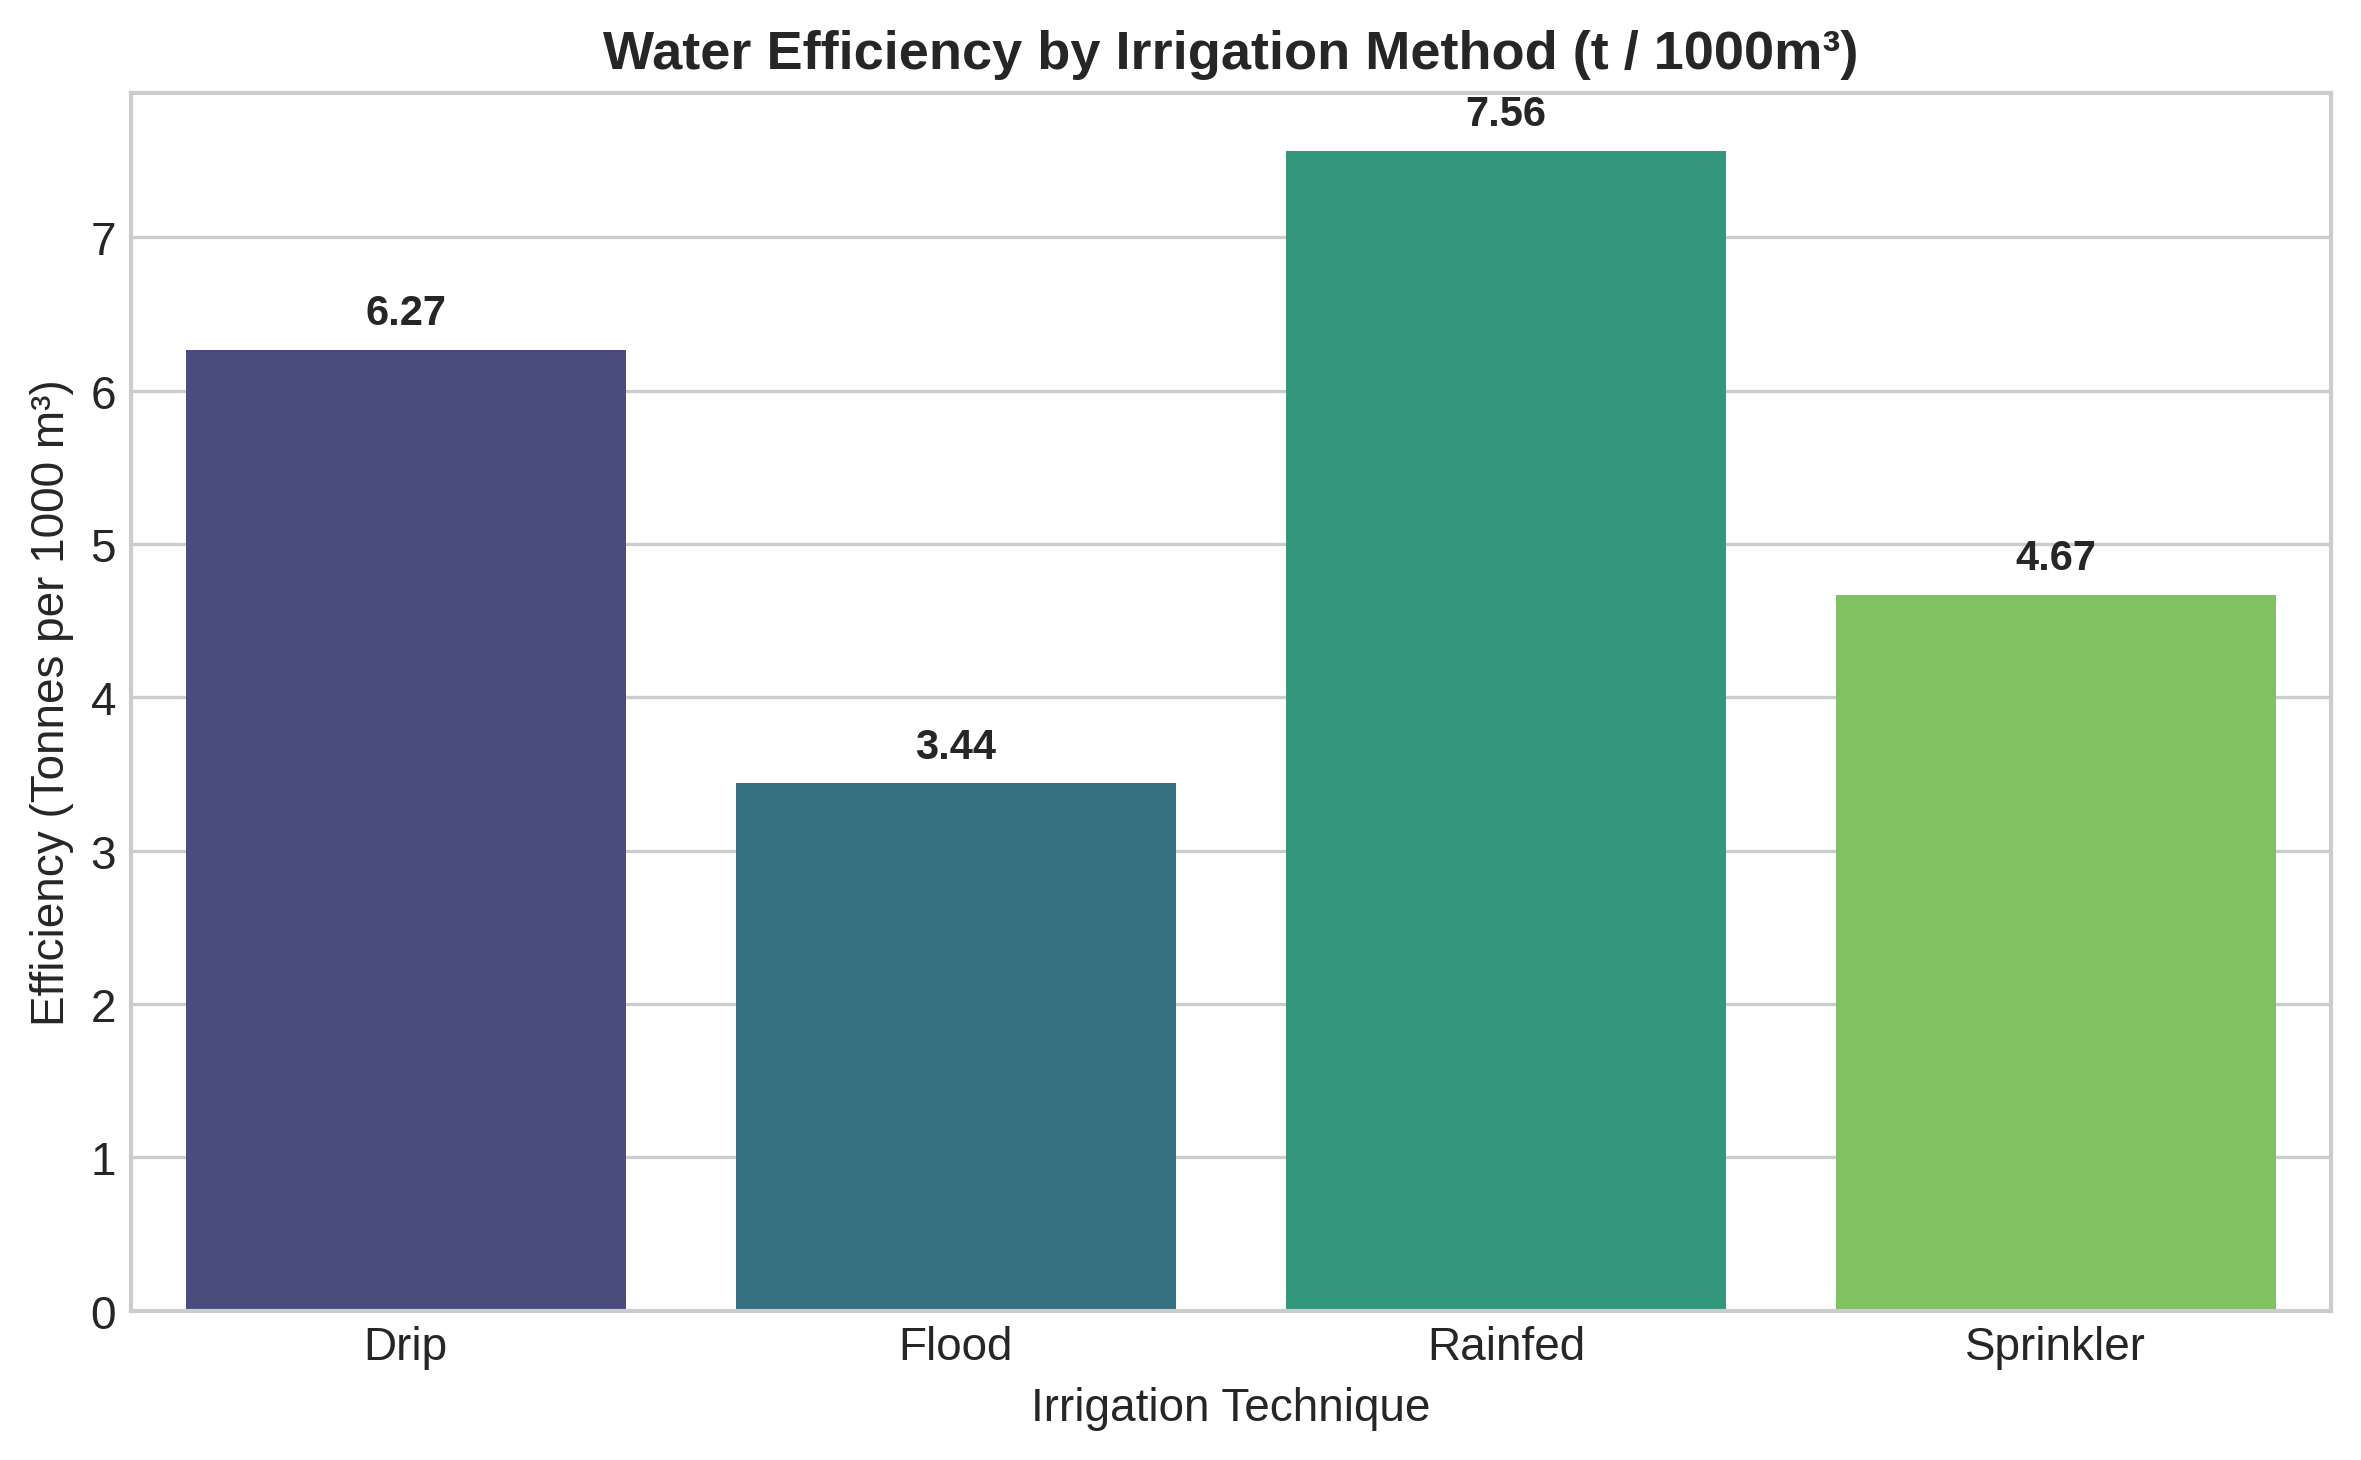

In [8]:
# Cell 6: Water Efficiency Comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Efficiency_t_per_1000m3',
    palette='viridis',
    estimator=np.mean,
    ci=None,
)
plt.title(
    'Water Efficiency by Irrigation Method (t / 1000m³)',
    fontsize=13,
    fontweight='bold',
)
plt.ylabel('Efficiency (Tonnes per 1000 m³)')
plt.xlabel('Irrigation Technique')

for p in ax.patches:
  val = p.get_height()
  ax.annotate(
      f'{val:.2f}',
      (p.get_x() + p.get_width() / 2.0, val),
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
      xytext=(0, 4),
      textcoords='offset points',
  )

plt.tight_layout()
plt.savefig('plot2_irrigation_efficiency.png')
plt.show()

/tmp/ipykernel_2156/4116133567.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


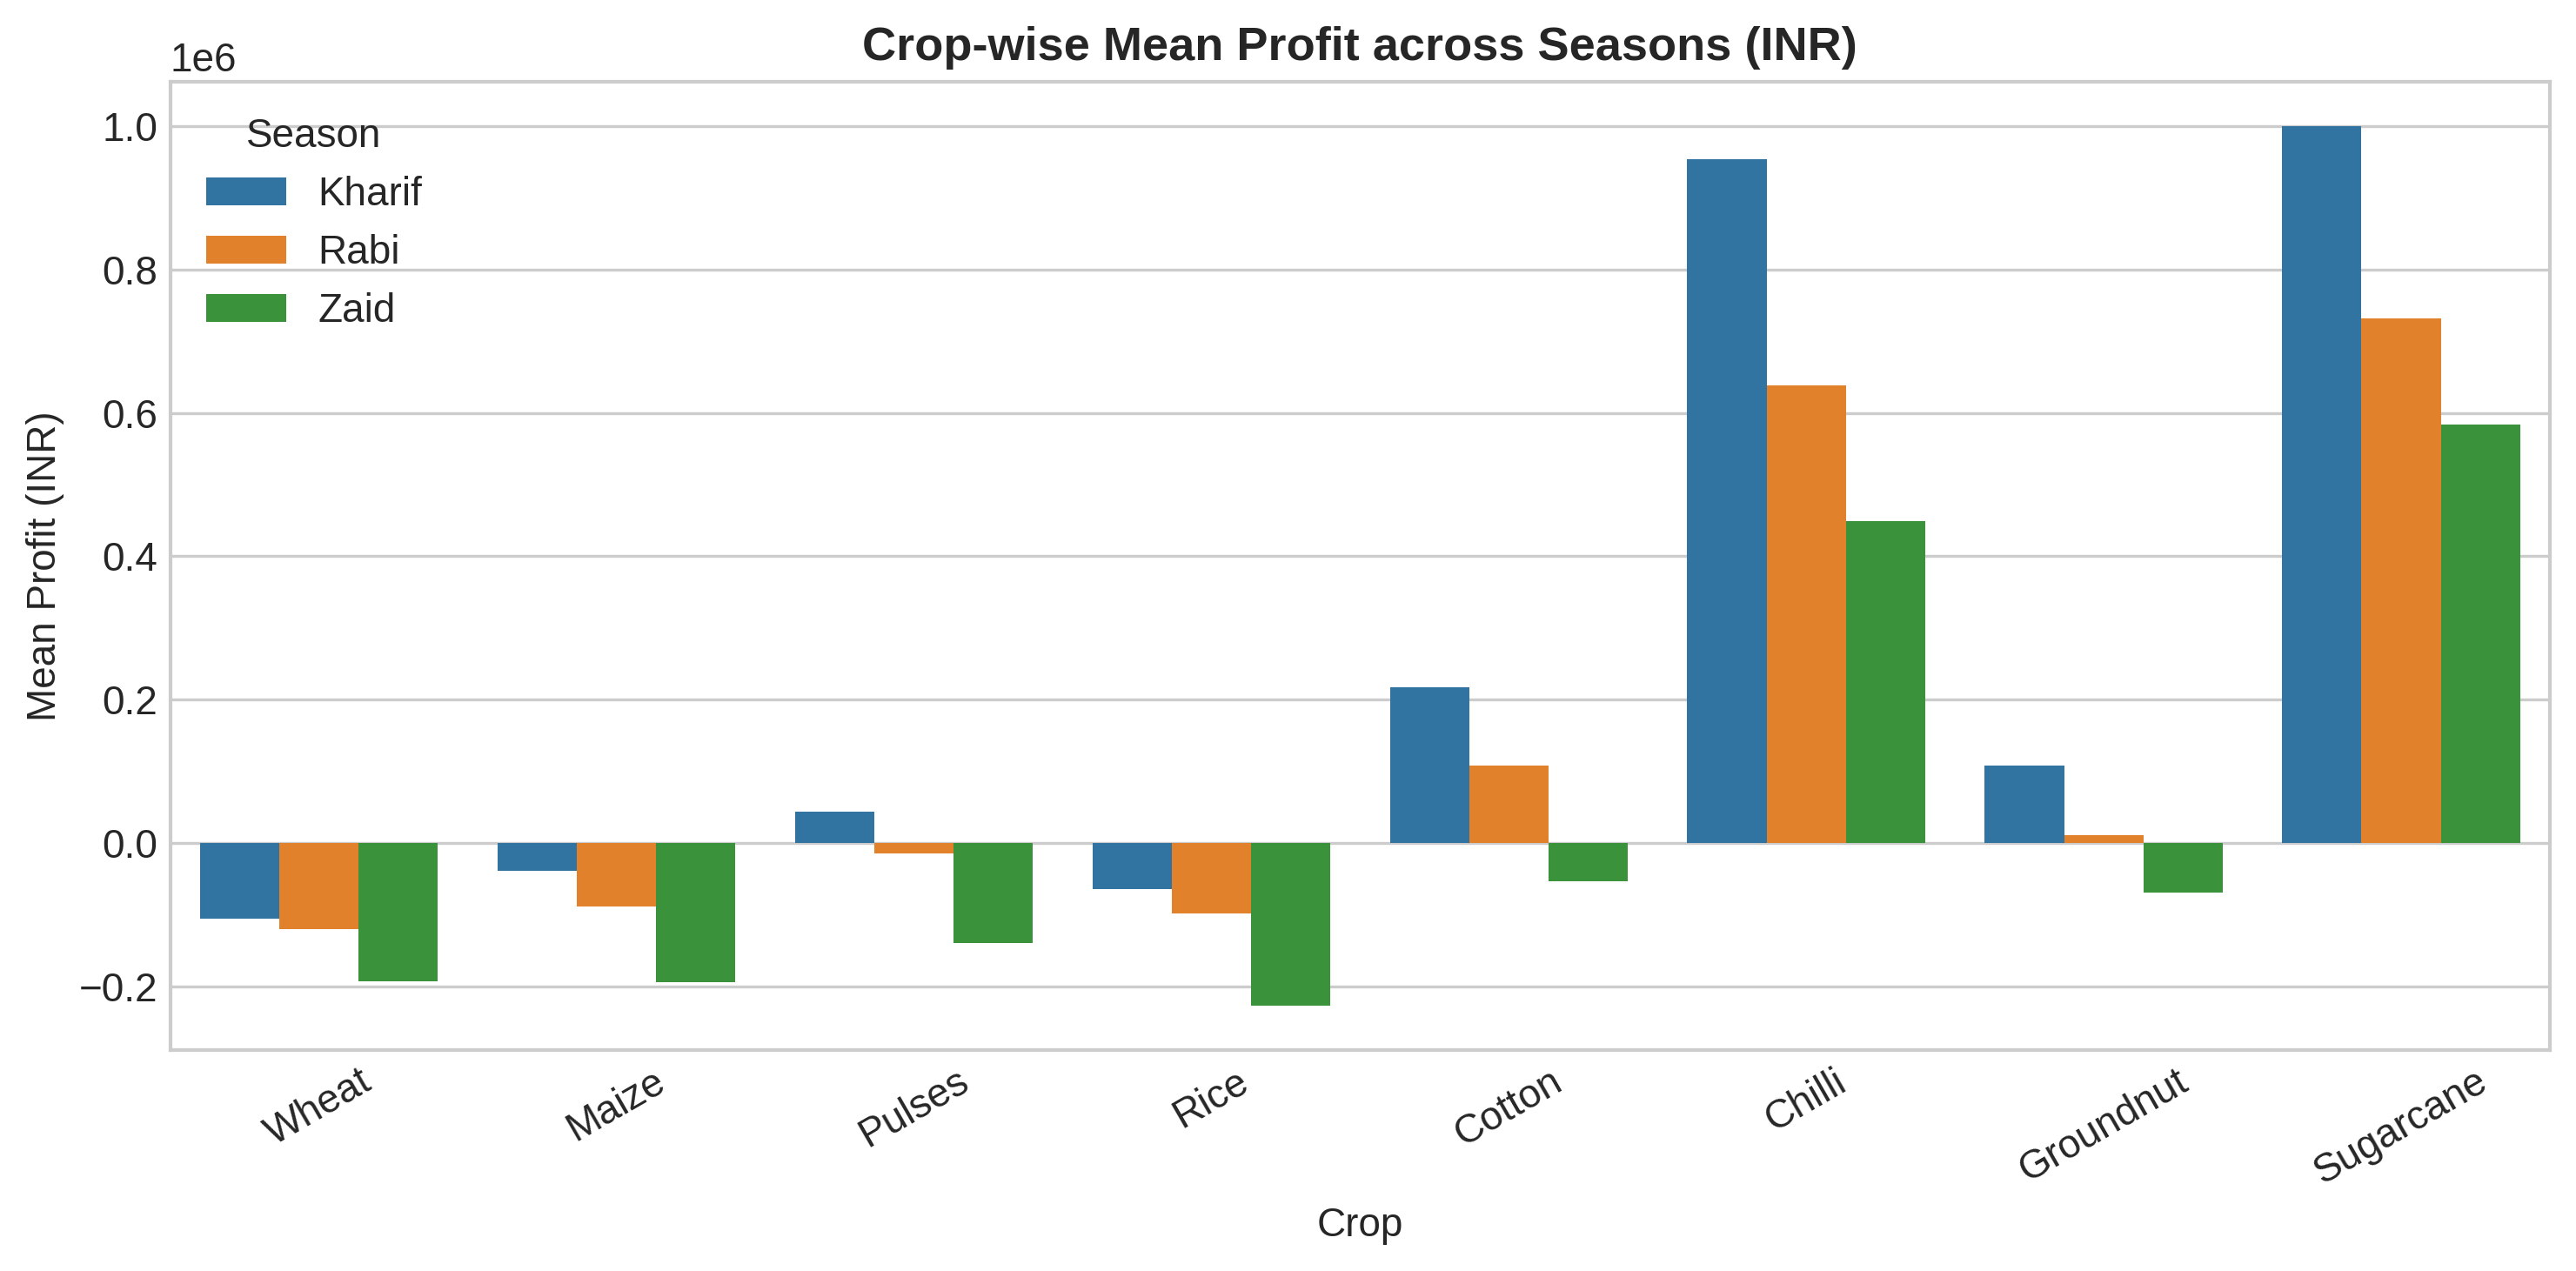

In [9]:
# Cell 7: Crop Profitability Matrix
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Crop',
    y='Profit_INR',
    hue='Season',
    palette='tab10',
    estimator=np.mean,
    ci=None,
)
plt.title(
    'Crop-wise Mean Profit across Seasons (INR)', fontsize=13, fontweight='bold'
)
plt.ylabel('Mean Profit (INR)')
plt.xlabel('Crop')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot3_crop_profit.png')
plt.show()

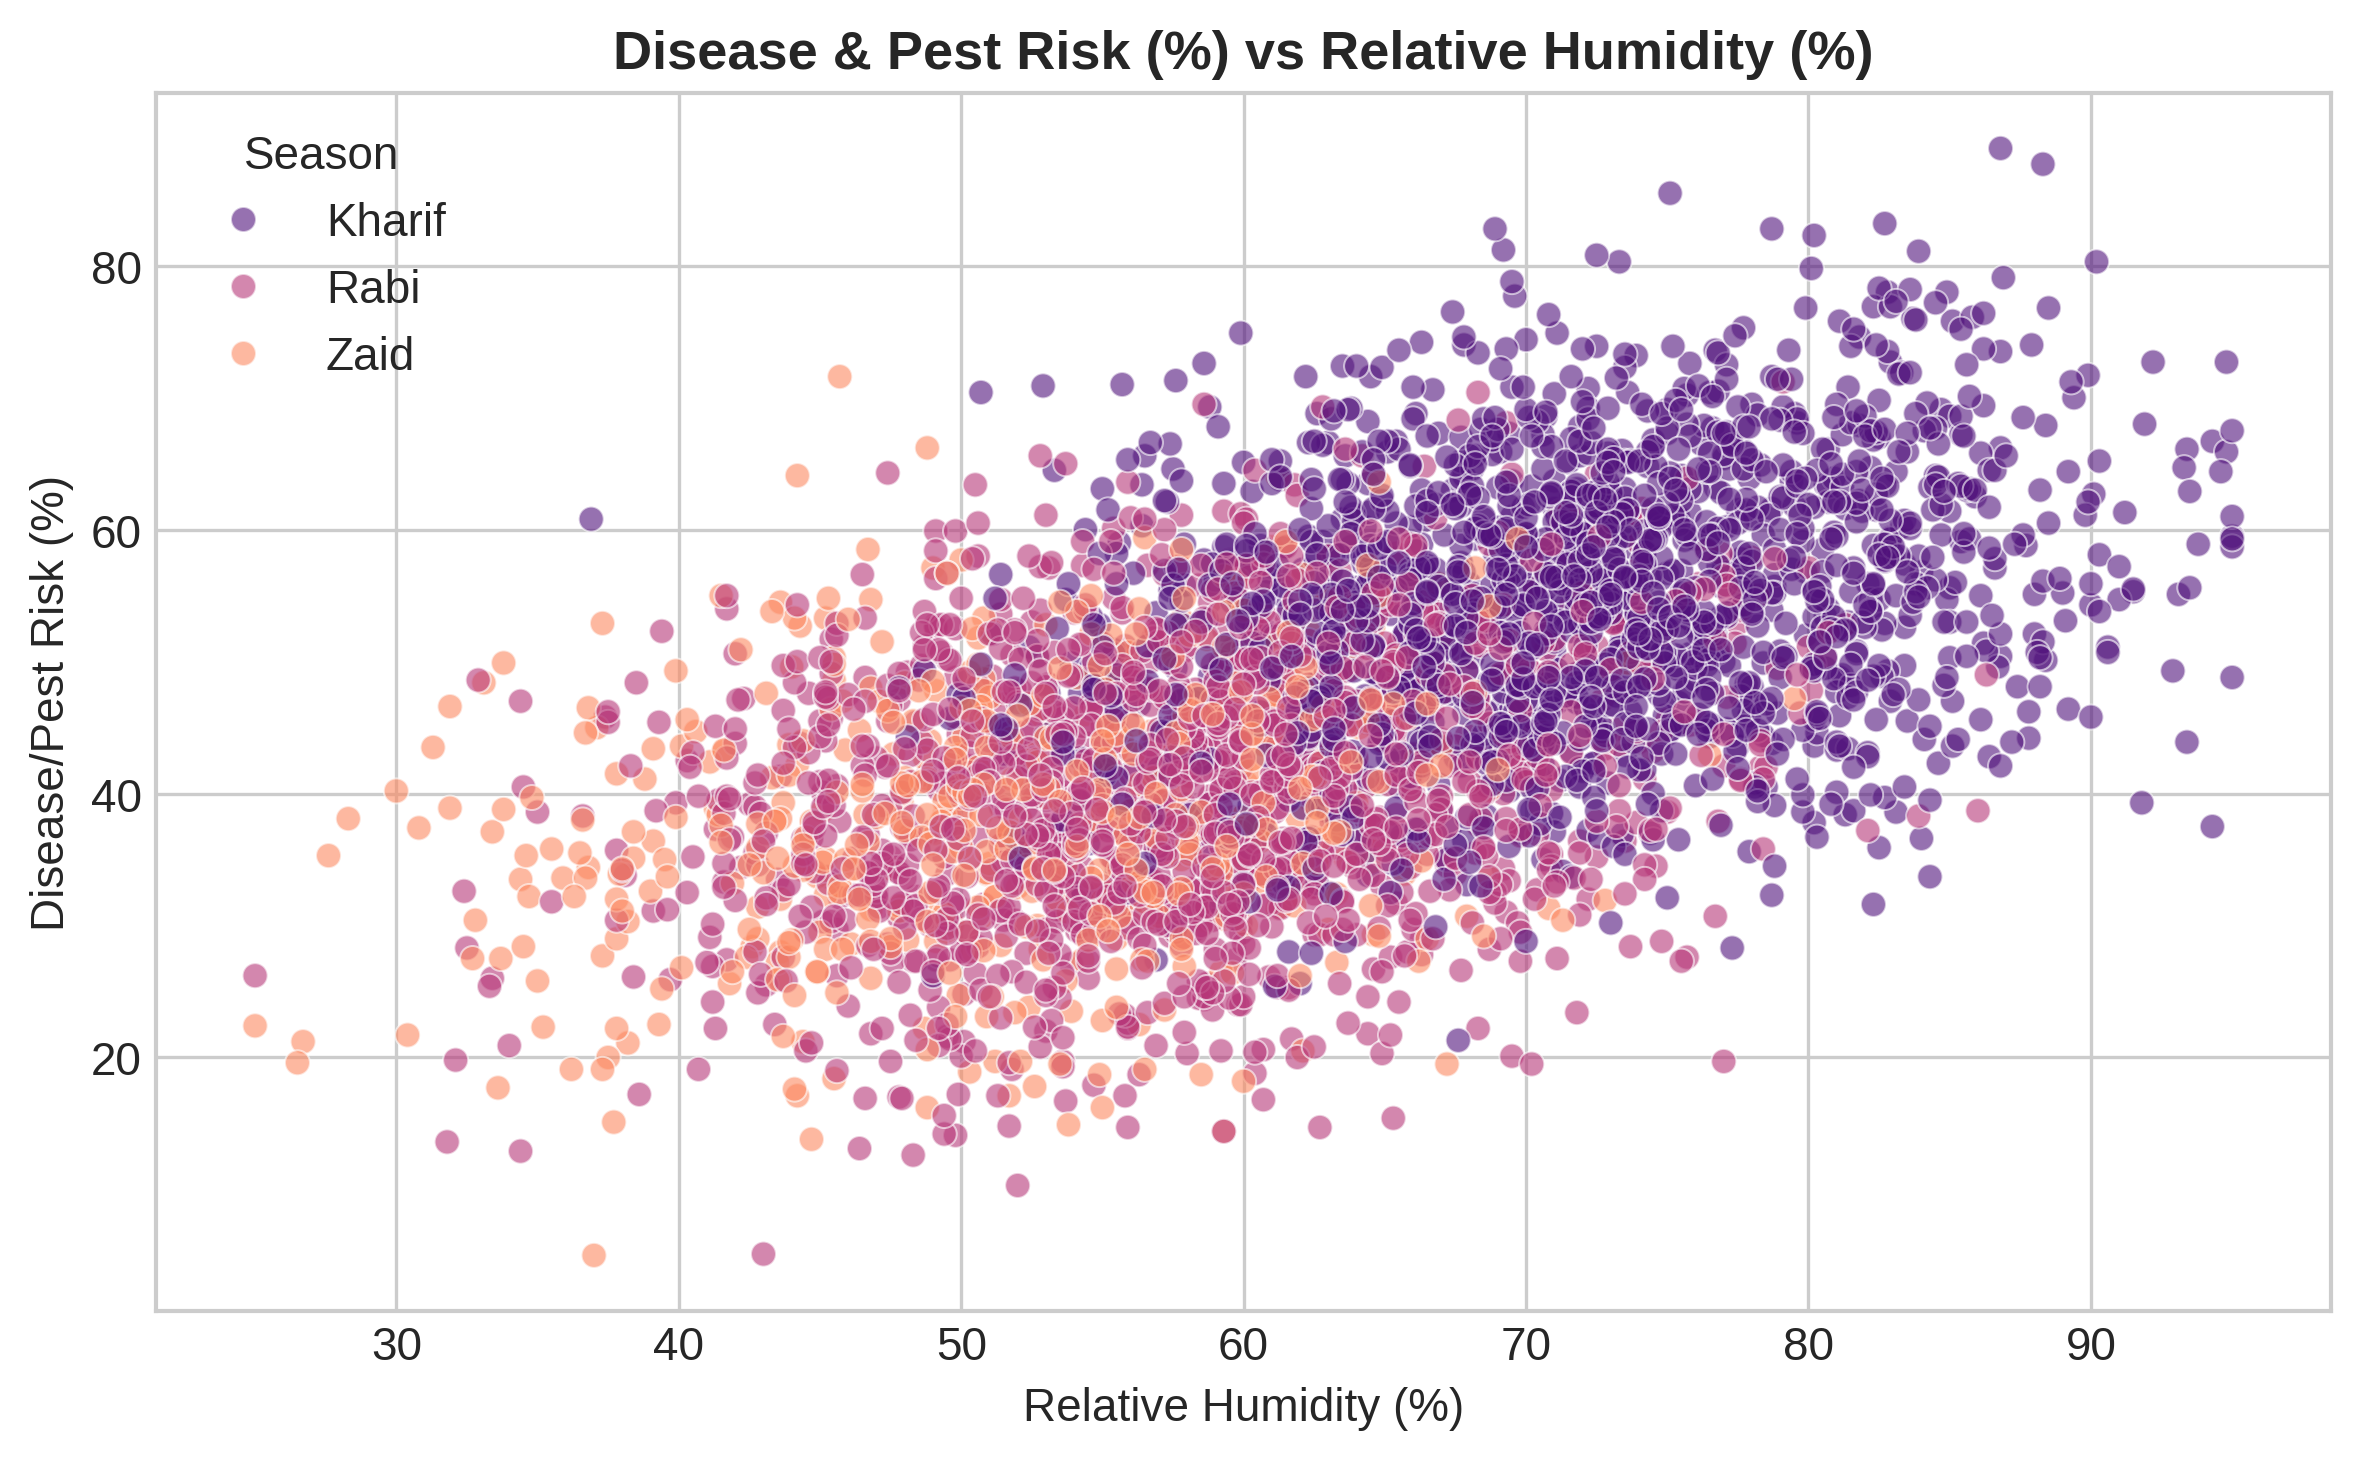

In [10]:
# Cell 8: Humidity vs Pest/Disease Vulnerability
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Humidity_pct',
    y='Disease_Pest_Risk_pct',
    hue='Season',
    alpha=0.6,
    palette='magma',
)
plt.title(
    'Disease & Pest Risk (%) vs Relative Humidity (%)',
    fontsize=13,
    fontweight='bold',
)
plt.ylabel('Disease/Pest Risk (%)')
plt.xlabel('Relative Humidity (%)')
plt.tight_layout()
plt.savefig('plot4_disease_humidity.png')
plt.show()

Model Evaluation:
R² Score: -0.0682
MAE: 7.4037
RMSE: 14.3504


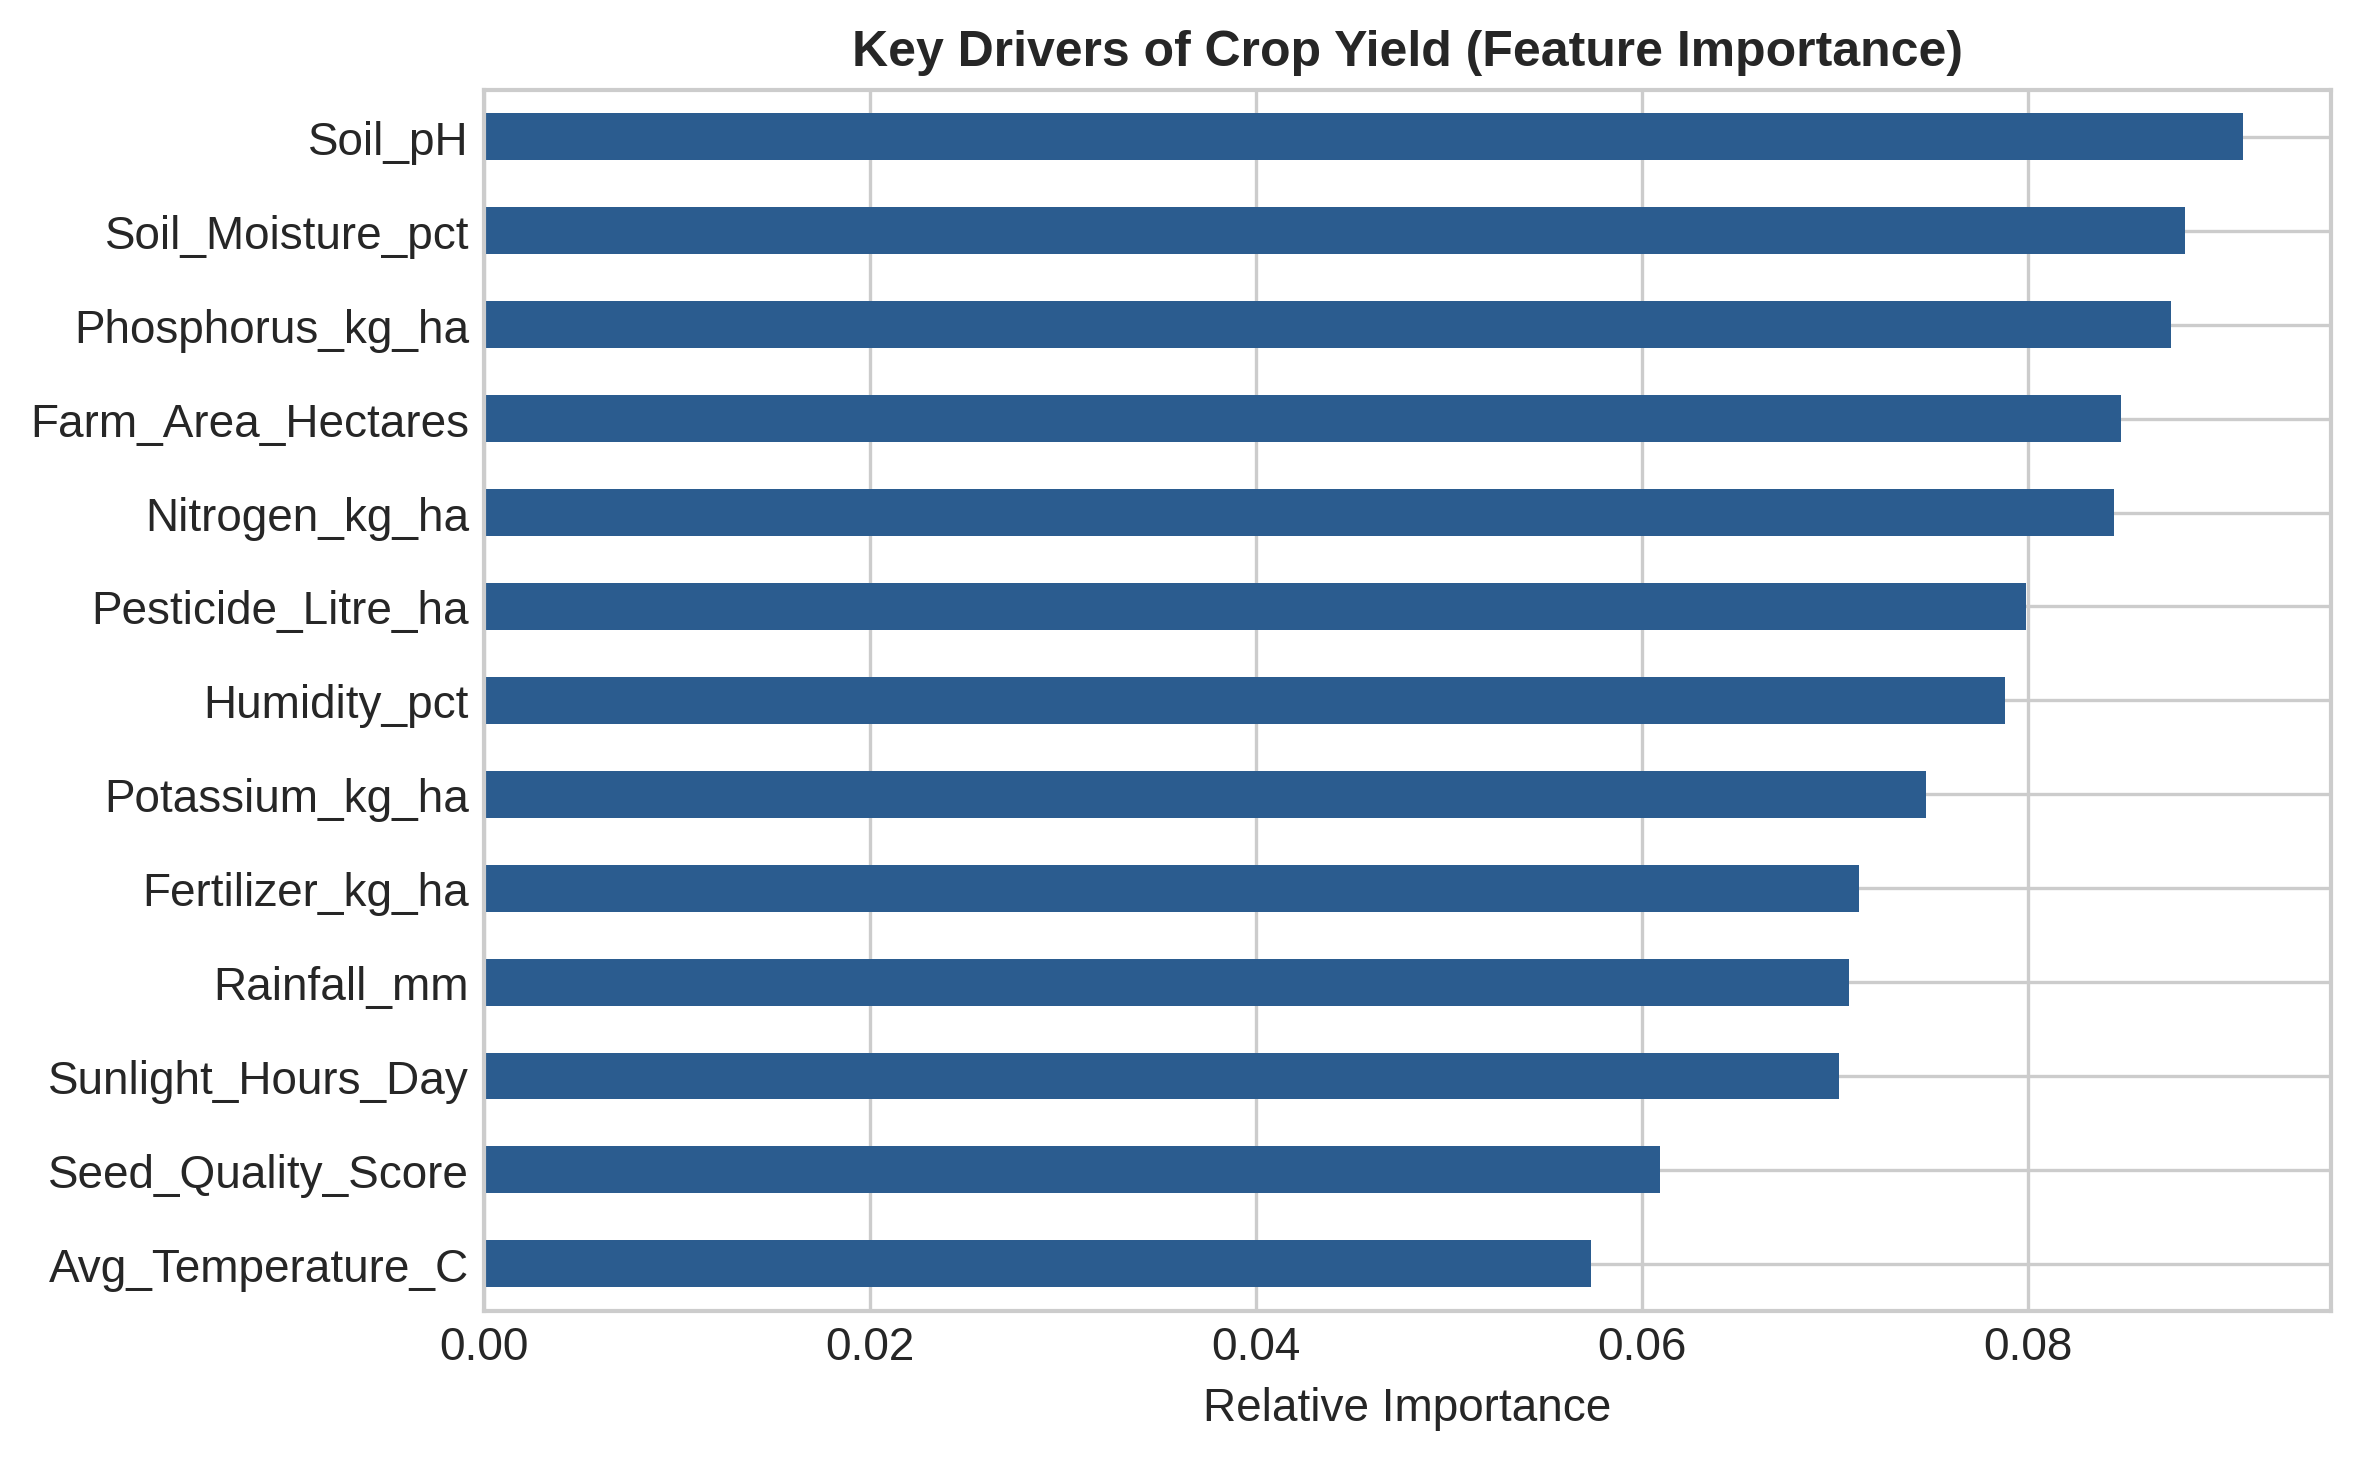

In [11]:
# Cell 9: Feature Importance for Crop Yield Prediction
features = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
]

X = df[features]
y = df['Yield_Tonnes_Ha']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f'Model Evaluation:')
print(f'R² Score: {r2_score(y_test, y_pred):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')

# Feature importance plot
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(
    ascending=True
)
plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='#2b5c8f')
plt.title(
    'Key Drivers of Crop Yield (Feature Importance)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('plot5_feature_importance.png')
plt.show()